Here’s a ready‑to‑paste Jupyter‑Notebook markdown layout, broken into clear theory blocks (with LaTeX), code explanations, two “connection” blocks per your format, an example/industry practice section, and a final tips block. Just copy each triple‑backticked cell into your notebook:


# 1. Shifted Geometric Brownian Motion (GBM)

$ \displaystyle S_t = e^{X_t} - \text{shift},\quad 
   dX_t = \Bigl(r - \tfrac12\sigma^2\Bigr)\,dt \;+\;\sigma\,dW_t $

**Theory & Mathematics**

$$
X_{t+\Delta t}
= X_t + \Bigl(r - \tfrac12\sigma^2\Bigr)\Delta t 
  + \sigma\bigl(W_{t+\Delta t}-W_t\bigr),
\quad W_{t+\Delta t}-W_t\sim\mathcal{N}(0,\Delta t).
$$

**Code Explanation**  
- We draw $Z\sim\mathcal{N}(0,1)$ and enforce zero mean/unit variance:  
  `Z[:,i] = (Z[:,i]–Z[:,i].mean())/Z[:,i].std()`  
- Build Brownian path $W$ via cumulative sums of $\sqrt{\Delta t}\,Z$.  
- Log‐price $X$ stepped by $(r-\tfrac12\sigma^2)\Delta t + \sigma\,\Delta W$.  
- Finally, exponentiate $X$ and subtract the shift to get $S$.

**Connection to Quant Finance**  
> Shifted‐GBM is used to model assets that can go negative—like interest rates or credit‐spreads—while preserving lognormal dispersion for large values.

**Nitish Sir ka Explanation (Hinglish)**  
> “Bro, jab interest rates ya spread negative ho sakte hain, to simple GBM fail ho jata. ‘Shift’ add karke hum log‐normal ko adjust kar dete, taaki simulation realistic mile.”

**Example & Industry Practice**  
- *Example:* Calibrating a shifted GBM to EUR‑OIS rate cap/floor market.  
- *Practice:* Dealers fit the shift so that implied cap prices are accurate, then simulate future rates for risk metrics.

---



# 2. Black–Scholes Call/Put with Shift

$ \displaystyle C(S_0,K) 
= e^{-r\tau}\bigl[\,\Phi(d_1)\,S_0 - \Phi(d_2)\,K\,\bigr], 
\quad d_{1,2} = \frac{\ln\frac{S_0}{K} + (r\pm\tfrac12\sigma^2)\tau}{\sigma\sqrt{\tau}}\,. $

For a shifted model replace $S_0\to S_0+\text{shift}$, $K\to K+\text{shift}$.

**Theory & Mathematics**

$$
d_1=\frac{\ln\frac{S_0+\delta}{K+\delta} + \bigl(r+\tfrac12\sigma^2\bigr)\tau}{\sigma\sqrt{\tau}},\quad
d_2=d_1-\sigma\sqrt{\tau}.
$$

**Code Explanation**  
- `stats.norm.cdf(d1)` and `stats.norm.cdf(d2)` compute $\Phi(d)$, the standard normal CDF.  
- Call: $\Phi(d_1)S_0 - \Phi(d_2)K e^{-r\tau}$; Put by put–call parity or direct formula.

**Connection to Quant Finance**  
> Shifted Black–Scholes lets quants price options on underlyings like rates or spreads that sometimes go negative, while keeping closed‑form tractability.

**Nitish Sir ka Explanation (Hinglish)**  
> “Yaar, jab stock negative ho hi nahi sakta, normal BS thik hai. But agar rate negative jaye, to $S_0+\delta$, $K+\delta$ shift karke formula use karte.”

**Example & Industry Practice**  
- *Example:* Pricing a floor on Euribor using shifted Black–Scholes.  
- *Practice:* Traders pick shift to match market vol skew, then plug into BS for speedy pricing.

---

# 3. Implied Volatility via Newton’s Method

We invert $C_{\rm BS}(\sigma)$ to find $\sigma_{\rm imp}$ s.t.  
$$C_{\rm BS}(\sigma_{\rm imp}) = C_{\rm market}.$$

**Theory & Mathematics**

1. Build a grid $\{\sigma_i\}$ and compute $C_{\rm BS}(\sigma_i)$.
2. Interpolate to get initial guess $\sigma_0$.
3. Refine via Newton:
$$
\sigma_{n+1} = \sigma_n 
  - \frac{C_{\rm BS}(\sigma_n)-C_{\rm mkt}}{\partial C_{\rm BS}/\partial\sigma\,(\sigma_n)}.
$$

**Code Explanation**  
- `np.interp` gives $\sigma_0$ by inverting on the grid.  
- `optimize.newton` refines using your lambda as $f(\sigma)=C(\sigma)-C_{\rm mkt}$.

**Connection to Quant Finance**  
> Implied vols are the market’s view of future volatility, crucial for risk management, hedging, and trade structuring.

**Nitish Sir ka Explanation (Hinglish)**  
> “Newton method se hum quickly implied vol nikal lete—market price ko BS formula ke against invert kar ke.”

**Example & Industry Practice**  
- *Example:* Calibrating vol surface for equity options.  
- *Practice:* Real‑time systems fit smiles every few seconds so traders have current skews.

---

# 4. Monte Carlo vs. Analytical Comparison

We compare MC estimate  
$$\hat C_{\rm MC} = e^{-rT}\,\mathbb{E}\bigl[\max(S_T-K,0)\bigr]$$  
with shifted BS closed form.

**Theory & Mathematics**

- MC: simulate many paths $S_T^{(i)}$, average payoff.
- Analytical: use shifted BS formula.

**Code Explanation**  
- Loop strikes $K_j$, compute `optPriceMCV[j]` via `np.maximum`.  
- Plot against `BS_Call_Put_Option_Price_Shifted`.

**Connection to Quant Finance**  
> MC lets you price path‑dependent or exotic payoffs where no closed‑form exists; analytic formulas serve as fast benchmarks.

**Nitish Sir ka Explanation (Hinglish)**  
> “MC slow hai but flexible—exotic ya path‑dependent pricing. BS fast but sirf vanillas ke liye.”

**Example & Industry Practice**  
- *Example:* Pricing barrier options via MC vs. closed‑form approximate.  
- *Practice:* Front office uses analytic, back‑office uses MC for Greeks/validation.

---

# 5. Tips for Your Quant Interview

1. **Understand the Maths**: Derive BS and GBM on paper—know each step.  
2. **Code Efficiency**: Vectorize NumPy operations; avoid Python loops.  
3. **Model Building**:  
   - Calibrate shift and vol surfaces from market data.  
   - Implement MC with antithetic variates or control variates for variance reduction.  
   - Compare analytics vs. MC for sanity checks.  
4. **Industry Practice**: Talk about how you’d deploy in a production system (latency, parallelization, calibration).  
5. **Soft Skills**: Explain your assumptions clearly, discuss limitations and possible extensions (stochastic vol, local vol).

All the best for your Mumbai quant internship prep! 🚀  
```

-0.0500413076942476


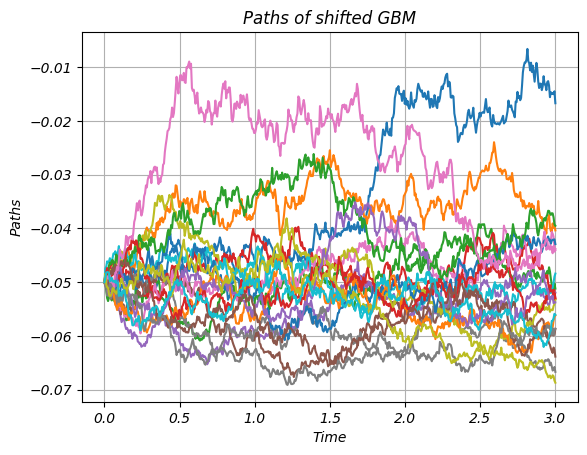

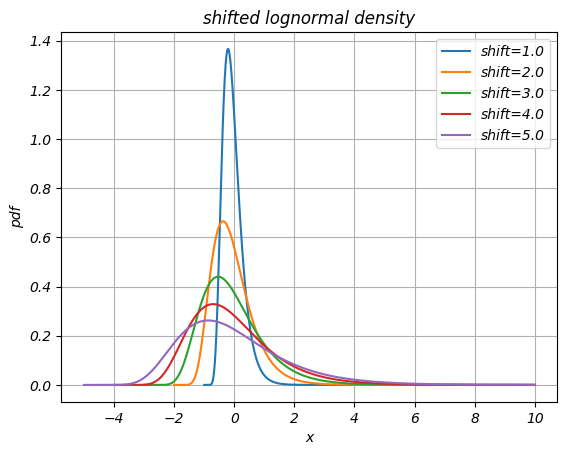

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11128\1491413230.py:57: RuntimeWarning: divide by zero encountered in divide
  d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) * tau) / (sigma * np.sqrt(tau))


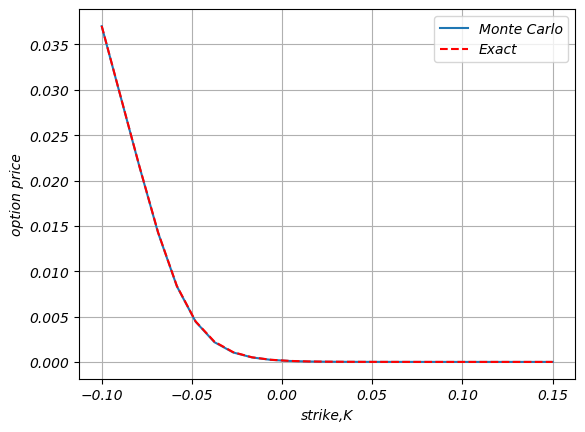

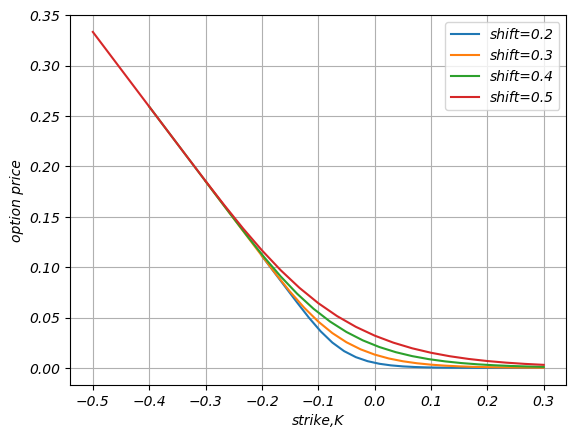

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import enum
import scipy.optimize as optimize


class OptionType(enum.Enum):
    CALL = 1.0
    PUT = -1.0


def GeneratePathsGBMShifted(NoOfPaths, NoOfSteps, T, r, sigma, S_0, shift):
    S_0shift = S_0 + shift
    if (S_0shift < 0.0):
        raise ('Shift is too small!')

    paths = GeneratePathsGBM(NoOfPaths, NoOfSteps, T, r, sigma, S_0shift)
    Sshifted = paths["S"] - shift
    time = paths["time"]
    return {"time": time, "S": Sshifted}


def GeneratePathsGBM(NoOfPaths, NoOfSteps, T, r, sigma, S_0):
    Z = np.random.normal(0.0, 1.0, [NoOfPaths, NoOfSteps])
    X = np.zeros([NoOfPaths, NoOfSteps + 1])
    W = np.zeros([NoOfPaths, NoOfSteps + 1])
    time = np.zeros([NoOfSteps + 1])

    X[:, 0] = np.log(S_0)

    dt = T / float(NoOfSteps)
    for i in range(0, NoOfSteps):
        # making sure that samples from normal have mean 0 and variance 1
        if NoOfPaths > 1:
            Z[:, i] = (Z[:, i] - np.mean(Z[:, i])) / np.std(Z[:, i])
        W[:, i + 1] = W[:, i] + np.power(dt, 0.5) * Z[:, i]
        X[:, i + 1] = X[:, i] + (r - 0.5 * sigma * sigma) * dt + sigma * (W[:, i + 1] - W[:, i])
        time[i + 1] = time[i] + dt

    # Compute exponent of ABM
    S = np.exp(X)
    paths = {"time": time, "S": S}
    return paths


# Shifted Black-Scholes Call option price
def BS_Call_Put_Option_Price_Shifted(CP,S_0,K,sigma,tau,r,shift):
    K_new = K + shift
    S_0_new = S_0 + shift
    return BS_Call_Put_Option_Price(CP,S_0_new,K_new,sigma,tau,r)

def BS_Call_Put_Option_Price(CP,S_0,K,sigma,tau,r):
    global value
    if K is list:
        K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) * tau) / (sigma * np.sqrt(tau))
    d2    = d1 - sigma * np.sqrt(tau)
    if CP == OptionType.CALL:
        value = stats.norm.cdf(d1) * S_0 - stats.norm.cdf(d2) * K * np.exp(-r * tau)
    elif CP == OptionType.PUT:
        value = stats.norm.cdf(-d2) * K * np.exp(-r * tau) - stats.norm.cdf(-d1) * S_0
    return value


def ImpliedVolatilityBlack76(CP, marketPrice, K, T, S_0):
    # To determine initial volatility we interpolate define a grid for sigma
    # and interpolate on the inverse
    sigmaGrid = np.linspace(0.0, 2.0, 5000)
    optPriceGrid = BS_Call_Put_Option_Price(CP, S_0, K, sigmaGrid, T, 0.0)
    sigmaInitial = np.interp(marketPrice, optPriceGrid, sigmaGrid)
    print("Initial volatility = {0}".format(sigmaInitial))

    # Use determined input for the local-search (final tuning)
    func = lambda sigma: np.power(BS_Call_Put_Option_Price(CP, S_0, K, sigma, T, 0.0) - marketPrice, 1.0)
    impliedVol = optimize.newton(func, sigmaInitial, tol=1e-15)
    print("Final volatility = {0}".format(impliedVol))
    return impliedVol


# Implied volatility method
def ImpliedVolatilityBlack76Shifted(CP, marketPrice, K, T, S_0, shift):
    # To determine initial volatility we interpolate define a grid for sigma
    # and interpolate on the inverse
    sigmaGrid = np.linspace(0.0, 2.0, 5000)
    optPriceGrid = BS_Call_Put_Option_Price_Shifted(CP, S_0, K, sigmaGrid, T, 0.0, shift)
    sigmaInitial = np.interp(marketPrice, optPriceGrid, sigmaGrid)
    print("Initial volatility = {0}".format(sigmaInitial))

    # Use determined input for the local-search (final tuning)
    func = lambda sigma: np.power(BS_Call_Put_Option_Price_Shifted(CP, S_0, K, sigma, T, 0.0, shift) - marketPrice, 1.0)
    impliedVol = optimize.newton(func, sigmaInitial, tol=1e-15)
    print("Final volatility = {0}".format(impliedVol))
    return impliedVol


def mainCalculation():
    NoOfPaths = 10000
    NoOfSteps = 500
    T = 3.0
    sigma = 0.2
    L0 = -0.05
    shift = 0.1
    K = [0.95]
    CP = OptionType.CALL

    P0T = lambda T: np.exp(-0.1 * T)

    np.random.seed(4)
    Paths = GeneratePathsGBMShifted(NoOfPaths, NoOfSteps, T, 0.0, sigma, L0, shift)
    time = Paths["time"]
    L = Paths["S"]

    print(np.mean(L[:, -1]))
    plt.figure(1)
    plt.plot(time, np.transpose(L[0:20, :]))
    plt.grid()
    plt.xlabel('Time')
    plt.ylabel('Paths')
    plt.title('Paths of shifted GBM')
    plt.show()

    plt.figure(2)
    shiftV = [1.0, 2.0, 3.0, 4.0, 5.0]
    legend = []
    for shiftTemp in shiftV:
        x = np.linspace(-shiftTemp, 10, 1000)
        lognnormPDF = lambda x, t: stats.lognorm.pdf(x + shiftTemp,
                                                     scale=np.exp(np.log(L0 + shiftTemp) + (- 0.5 * sigma * sigma) * t),
                                                     s=np.sqrt(t) * sigma)
        pdf_x = lognnormPDF(x, T)
        plt.plot(x, pdf_x)
        legend.append('shift={0}'.format(shiftTemp))
    plt.legend(legend)
    plt.xlabel('x')
    plt.ylabel('pdf')
    plt.title('shifted lognormal density')
    plt.grid()
    plt.show()

    # Call/Put option prices, MC vs. Analytical
    plt.figure(3)
    K = np.linspace(-shift, np.abs(L0) * 3, 25)
    optPriceMCV = np.zeros([len(K), 1])
    for idx in range(0, len(K)):
        optPriceMCV[idx] = 0.0
        if CP == OptionType.CALL:
            optPriceMCV[idx] = P0T(T) * np.mean(np.maximum(L[:, -1] - K[idx], 0.0))
        elif CP == OptionType.PUT:
            optPriceMCV[idx] = P0T(T) * np.mean(np.maximum(K[idx] - L[:, -1], 0.0))

    optPriceExact = P0T(T) * BS_Call_Put_Option_Price_Shifted(CP, L0, K, sigma, T, 0.0, shift)
    plt.plot(K, optPriceMCV)
    plt.plot(K, optPriceExact, '--r')
    plt.grid()
    plt.xlabel('strike,K')
    plt.ylabel('option price')
    plt.legend(['Monte Carlo', 'Exact'])

    # Shift Effect on Option prices
    plt.figure(4)
    legend = []
    for shiftTemp in [0.2, 0.3, 0.4, 0.5]:
        K = np.linspace(-shiftTemp, np.abs(L0) * 6.0, 25)
        optPriceExact = P0T(T) * BS_Call_Put_Option_Price_Shifted(CP, L0, K, sigma, T, 0.0, shiftTemp)
        plt.plot(K, optPriceExact)
        legend.append('shift={0}'.format(shiftTemp))
    plt.grid()
    plt.xlabel('strike,K')
    plt.ylabel('option price')
    plt.legend(legend)



mainCalculation()
